In [ ]:
# Install IDC index and other dependencies
!pip install idc-index openslide-bin openslide-python pillow tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 84.0 MB/s eta 0:00:00


In [ ]:
import os
import io
import json
import time
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import requests

from PIL import Image
import openslide

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import EfficientNetB0

from idc_index import index

from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
CACHE_PATH = "ffpe_series.csv"

if os.path.exists(CACHE_PATH):
    ffpe_series = pd.read_csv(CACHE_PATH)
else:
    client = index.IDCClient()
    ffpe_series = client.sql_query("""
        SELECT
            PatientID,
            SeriesInstanceUID,
            SeriesDescription,
            series_size_MB,
            series_aws_url
        FROM index
        WHERE collection_id = 'tcga_hnsc'
        AND Modality = 'SM'
        AND SeriesDescription = 'FFPE HE TP DX1'
    """)
    ffpe_series.to_csv(CACHE_PATH, index=False)

print(f"Slides: {len(ffpe_series)}")
print(f"Patients: {ffpe_series['PatientID'].nunique()}")

Slides: 450
Patients: 450


In [ ]:
def fetch_gdc_cases():
    url = "https://api.gdc.cancer.gov/cases"

    params = {
        "filters": '{"op":"=","content":{"field":"project.project_id","value":"TCGA-HNSC"}}',
        "fields": ",".join([
            "submitter_id",
            "diagnoses.tissue_or_organ_of_origin",
            "diagnoses.ajcc_pathologic_stage",
            "diagnoses.tumor_grade",
        ]),
        "format": "JSON",
        "size": "2000",
        "expand": "diagnoses"
    }

    for _ in range(3):
        r = requests.get(url, params=params)
        if r.status_code == 200:
            return r.json()
        time.sleep(2)

    raise Exception("Failed API request")

gdc_full = fetch_gdc_cases()
print(f"Cases fetched: {len(gdc_full['data']['hits'])}")

Cases fetched: 528


In [ ]:
records = []

for case in gdc_full['data']['hits']:
    pid = case.get('submitter_id')

    for diag in case.get('diagnoses', []):
        if not diag.get('diagnosis_is_primary_disease', False):
            continue

        records.append({
            'PatientID': pid,
            'site': diag.get('tissue_or_organ_of_origin'),
            'stage': diag.get('ajcc_pathologic_stage'),
            'grade': diag.get('tumor_grade'),
        })

clinical_df = pd.DataFrame(records)
clinical_df['site'] = clinical_df['site'].str.strip()

print(clinical_df['site'].value_counts())

site
Tongue, NOS                                           131
Larynx, NOS                                           118
Overlapping lesion of lip, oral cavity and pharynx     70
Floor of mouth, NOS                                    55
Tonsil, NOS                                            42
Base of tongue, NOS                                    25
Mouth, NOS                                             23
Cheek mucosa                                           19
Oropharynx, NOS                                        11
Hypopharynx, NOS                                        8
Gum, NOS                                                8
Hard palate                                             3
Lip, NOS                                                3
Lower gum                                               2
Anterior floor of mouth                                 2
Mandible                                                1
Supraglottis                                            1
Palate, N

In [ ]:
SITE_MAP = {
    'Base of tongue, NOS': 'Oropharynx',
    'Tonsil, NOS': 'Oropharynx',
    'Oropharynx, NOS': 'Oropharynx',
    'Anterior wall of nasopharynx': 'Oropharynx',
    'Posterior wall of oropharynx': 'Oropharynx',
    'Lateral wall of oropharynx': 'Oropharynx',
    'Anterior surface of epiglottis': 'Oropharynx',

    'Floor of mouth, NOS': 'Oral Cavity',
    'Tongue, NOS': 'Oral Cavity',
    'Oral tongue': 'Oral Cavity',
    'Gum, NOS': 'Oral Cavity',
    'Palate, NOS': 'Oral Cavity',
    'Oral cavity, NOS': 'Oral Cavity',
    'Lip, NOS': 'Oral Cavity',
    'Hard palate': 'Oral Cavity',
    'Cheek mucosa': 'Oral Cavity',
    'Retromolar area': 'Oral Cavity',
    'Mouth, NOS': 'Oral Cavity',

    'Larynx, NOS': 'Larynx',
    'Glottis': 'Larynx',
    'Supraglottis': 'Larynx',
    'Subglottis': 'Larynx',
    'Anterior commissure of larynx': 'Larynx',

    'Hypopharynx, NOS': 'Hypopharynx',
    'Pyriform sinus': 'Hypopharynx',
    'Posterior pharyngeal wall': 'Hypopharynx',
    'Postcricoid region': 'Hypopharynx',
}

clinical_df['subsite'] = clinical_df['site'].map(SITE_MAP)

mapped = clinical_df.dropna(subset=['subsite'])

print(mapped['subsite'].value_counts())

subsite
Oral Cavity    244
Larynx         119
Oropharynx      79
Hypopharynx      8
Name: count, dtype: int64


In [ ]:
final_df = mapped.merge(
    ffpe_series[['PatientID','SeriesInstanceUID','series_size_MB','series_aws_url']],
    on='PatientID',
    how='inner'
)

final_df = final_df.drop_duplicates(subset=['SeriesInstanceUID'])

SUBSITE_TO_INT = {'Oral Cavity':0,'Larynx':1,'Oropharynx':2,'Hypopharynx':3}
final_df['subsite_label'] = final_df['subsite'].map(SUBSITE_TO_INT)

print(final_df['subsite'].value_counts())

final_df.head()

subsite
Oral Cavity    222
Larynx         106
Oropharynx      51
Hypopharynx      7
Name: count, dtype: int64


,PatientID,site,stage,grade,subsite,SeriesInstanceUID,series_size_MB,series_aws_url,subsite_label
0,TCGA-BB-4227,"Hypopharynx, NOS",Stage IVA,G2,Hypopharynx,1.3.6.1.4.1.5962.99.1.1600394021.179938475.163...,210.809916,s3://idc-open-data/8b91fcbe-e1d7-44bc-94a8-734...,3
1,TCGA-BB-4228,"Base of tongue, NOS",Stage III,GX,Oropharynx,1.3.6.1.4.1.5962.99.1.1585283019.627256364.163...,105.542112,s3://idc-open-data/7c8bddb1-af8f-4727-bc6d-f35...,2
2,TCGA-BA-4075,"Tongue, NOS",Stage III,G2,Oral Cavity,1.3.6.1.4.1.5962.99.1.1601894574.2140212515.16...,536.267024,s3://idc-open-data/ca0b3873-bf20-4fdb-861e-f5e...,0
3,TCGA-CN-6997,"Larynx, NOS",Stage IVA,G3,Larynx,1.3.6.1.4.1.5962.99.1.1600622464.225473974.163...,188.862050,s3://idc-open-data/655df2bf-4682-4bb6-b040-613...,1
4,TCGA-DQ-5629,"Larynx, NOS",None,G2,Larynx,1.3.6.1.4.1.5962.99.1.1556493448.2075633986.16...,2218.343284,s3://idc-open-data/d7126a50-dc90-4c8e-bd41-6e4...,1


In [ ]:
# ── Experiment configuration ──────────────────────────────────────────────────
SAMPLES_PER_CLASS    = 30
TILE_SIZE            = 299
MAX_TILES_PER_SLIDE  = 30
BATCH_SIZE           = 32
EPOCHS               = 15
SUBSITE_NAMES        = ['Oral Cavity', 'Larynx', 'Oropharynx', 'Hypopharynx']

OUTPUT_DIR = "tiles"
WSI_DIR    = "wsi"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WSI_DIR, exist_ok=True)

# ── Sample slides ─────────────────────────────────────────────────────────────
sampled_df = (
    final_df
    .groupby('subsite', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=42))
)

print("Slides per subsite:")
print(sampled_df['subsite'].value_counts())
print(f"\nEstimated download size: {sampled_df['series_size_MB'].sum() / 1024:.1f} GB")
print(f"Tile size              : {TILE_SIZE}×{TILE_SIZE}")
print(f"Max tiles per slide    : {MAX_TILES_PER_SLIDE}")
print(f"Max total tiles        : ~{len(sampled_df) * MAX_TILES_PER_SLIDE}")

Slides per subsite:
subsite
Larynx         30
Oral Cavity    30
Oropharynx     30
Hypopharynx     7
Name: count, dtype: int64

Estimated download size: 80.6 GB
Tile size              : 299×299
Max tiles per slide    : 30
Max total tiles        : ~2910


/tmp/ipykernel_40709/3247255700.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=42))


In [ ]:
def is_informative(tile, threshold=220):
    """Reject mostly white/background patches."""
    tile_np = np.array(tile.convert('RGB'))
    return tile_np.mean() < threshold


def tile_slide(slide_path, label, slide_id):
    """Extract random tissue patches from a WSI and save as JPGs."""
    try:
        slide = openslide.OpenSlide(slide_path)
    except Exception as e:
        print(f"  OpenSlide failed for {slide_id}: {e}")
        return 0

    width, height = slide.dimensions
    class_dir     = os.path.join(OUTPUT_DIR, str(label))
    os.makedirs(class_dir, exist_ok=True)

    rng          = np.random.RandomState(42)
    count        = 0
    max_x        = max(1, width  - TILE_SIZE)
    max_y        = max(1, height - TILE_SIZE)
    max_attempts = MAX_TILES_PER_SLIDE * 15
    attempts     = 0

    while count < MAX_TILES_PER_SLIDE and attempts < max_attempts:
        x = int(rng.randint(0, max_x))
        y = int(rng.randint(0, max_y))
        tile = slide.read_region(
            (x, y), 0, (TILE_SIZE, TILE_SIZE)
        ).convert('RGB')
        if is_informative(tile):
            tile.save(
                f"{class_dir}/{slide_id}_{count}.jpg",
                quality=90
            )
            count += 1
        attempts += 1

    slide.close()
    return count

In [ ]:
client      = index.IDCClient()
total_tiles = 0

for _, row in tqdm(sampled_df.iterrows(), total=len(sampled_df)):
    slide_id  = row['SeriesInstanceUID']
    label     = row['subsite_label']
    slide_dir = os.path.join(WSI_DIR, slide_id)
    os.makedirs(slide_dir, exist_ok=True)

    try:
        client.download_dicom_series(
            seriesInstanceUID=slide_id,
            downloadDir=slide_dir,
            quiet=True,
            show_progress_bar=False
        )

        slide_path = None
        for root, dirs, files in os.walk(slide_dir):
            for file in files:
                if file.endswith((".svs", ".tif", ".tiff", ".dcm")):
                    slide_path = os.path.join(root, file)
                    break
            if slide_path:
                break

        if slide_path is None:
            print(f"No slide found for {slide_id}")
            shutil.rmtree(slide_dir)
            continue

        n = tile_slide(slide_path, label, slide_id)
        total_tiles += n
        shutil.rmtree(slide_dir)

    except Exception as e:
        print(f"Error with {slide_id}: {e}")
        if os.path.exists(slide_dir):
            shutil.rmtree(slide_dir)

print(f"\nTotal tiles extracted: {total_tiles}")

100%|██████████| 97/97 [22:10<00:00, 13.72s/it]


Total tiles extracted: 2910


In [ ]:
print("Tile distribution per class:")
total = 0
for i, name in enumerate(SUBSITE_NAMES):
    class_dir = os.path.join(OUTPUT_DIR, str(i))
    count     = len(os.listdir(class_dir)) if os.path.exists(class_dir) else 0
    total    += count
    print(f"  {name:15s} (class {i}): {count} tiles")
print(f"  {'Total':15s}: {total} tiles")

Tile distribution per class:
  Oral Cavity     (class 0): 900 tiles
  Larynx          (class 1): 900 tiles
  Oropharynx      (class 2): 900 tiles
  Hypopharynx     (class 3): 210 tiles
  Total          : 2910 tiles


In [ ]:
IMG_SIZE = (TILE_SIZE, TILE_SIZE)

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Save class names before prefetch loses them
CLASS_NAMES = train_ds_raw.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.cache().prefetch(AUTOTUNE)
val_ds   = val_ds_raw.cache().prefetch(AUTOTUNE)

print(f"Class names : {CLASS_NAMES}")
print(f"Image size  : {IMG_SIZE}")

# Class weights for imbalance
all_labels    = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

Found 2910 files belonging to 4 classes.
Using 2328 files for training.
Found 2910 files belonging to 4 classes.
Using 582 files for validation.
Class names : ['0', '1', '2', '3']
Image size  : (299, 299)
Class weights: {0: np.float64(0.8005502063273727), 1: np.float64(0.8220338983050848), 2: np.float64(0.7918367346938775), 3: np.float64(3.6835443037974684)}


In [ ]:
def build_model(freeze_mode, head_type, input_size=TILE_SIZE):
    base_model = EfficientNetB0(
        input_shape=(input_size, input_size, 3),
        include_top=False,
        weights='imagenet'
    )

    if freeze_mode == 'frozen':
        base_model.trainable = False
        lr = 1e-3
    elif freeze_mode == 'full':
        base_model.trainable = True
        lr = 1e-5

    inputs = Input(shape=(input_size, input_size, 3))
    x      = base_model(inputs, training=(freeze_mode != 'frozen'))
    x      = layers.GlobalAveragePooling2D(name='embeddings')(x)

    if head_type == 'A':
        x = layers.Dense(128, activation='relu')(x)
    elif head_type == 'B':
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(4, activation='softmax')(x)
    model   = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


EXPERIMENTS = [
    {'name': 'E1_frozen_headA', 'freeze': 'frozen', 'head': 'A'},
    {'name': 'E2_frozen_headB', 'freeze': 'frozen', 'head': 'B'},
    {'name': 'E3_full_headA',   'freeze': 'full',   'head': 'A'},
    {'name': 'E4_full_headB',   'freeze': 'full',   'head': 'B'},
]

print(f"Total experiments : {len(EXPERIMENTS)}")
for e in EXPERIMENTS:
    print(f"  {e['name']:25s} freeze={e['freeze']:6s}  head={e['head']}")

Total experiments : 4
  E1_frozen_headA           freeze=frozen  head=A
  E2_frozen_headB           freeze=frozen  head=B
  E3_full_headA             freeze=full    head=A
  E4_full_headB             freeze=full    head=B


In [ ]:
experiment_results = []
experiment_histories = {}
best_model     = None
best_val_acc   = 0.0
best_exp_name  = ''

for exp in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"  Running: {exp['name']}")
    print(f"  Freeze: {exp['freeze']}  |  Head: {exp['head']}")
    print(f"{'='*60}")

    # Build fresh model for each experiment
    model = build_model(
        freeze_mode=exp['freeze'],
        head_type=exp['head'],
        input_size=TILE_SIZE
    )

    trainable_params = sum(
        np.prod(v.shape) for v in model.trainable_variables
    )
    print(f"  Trainable params: {trainable_params:,}")

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-7, verbose=0
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    # ── Evaluate ──────────────────────────────────────────────────────────────
    y_true_exp, y_pred_exp = [], []
    for imgs, lbls in val_ds:
        probs = model.predict(imgs, verbose=0)
        y_pred_exp.extend(np.argmax(probs, axis=1))
        y_true_exp.extend(lbls.numpy())

    y_true_exp = np.array(y_true_exp)
    y_pred_exp = np.array(y_pred_exp)

    acc = accuracy_score(y_true_exp, y_pred_exp)
    f1  = f1_score(y_true_exp, y_pred_exp, average='weighted')
    val_loss = min(history.history['val_loss'])

    print(f"\n  Val Accuracy : {acc:.4f}")
    print(f"  Val F1       : {f1:.4f}")
    print(f"  Best Val Loss: {val_loss:.4f}")

    experiment_results.append({
        'Experiment':  exp['name'],
        'Freeze Mode': exp['freeze'],
        'Head':        exp['head'],
        'Val Accuracy': round(acc, 4),
        'Val F1':       round(f1,  4),
        'Val Loss':     round(val_loss, 4),
        'Epochs Run':   len(history.history['loss']),
    })

    experiment_histories[exp['name']] = history.history

    # Track best model
    if acc > best_val_acc:
        best_val_acc  = acc
        best_model    = model
        best_exp_name = exp['name']
        best_y_true   = y_true_exp
        best_y_pred   = y_pred_exp

    # Save this experiment's model
    model.save(f"{exp['name']}.keras")

print(f"\n{'='*60}")
print(f"  Best experiment: {best_exp_name}  (Val Acc: {best_val_acc:.4f})")
print(f"{'='*60}")


  Running: E1_frozen_headA
  Freeze: frozen  |  Head: A
  Trainable params: 164,484
Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 605ms/step - accuracy: 0.3578 - loss: 1.3168 - val_accuracy: 0.4622 - val_loss: 1.1705 - learning_rate: 0.0010
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.4914 - loss: 1.1049 - val_accuracy: 0.5103 - val_loss: 1.0966 - learning_rate: 0.0010
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.5533 - loss: 0.9806 - val_accuracy: 0.5447 - val_loss: 1.0574 - learning_rate: 0.0010
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.6143 - loss: 0.8801 - val_accuracy: 0.5567 - val_loss: 1.0210 - learning_rate: 0.0010
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6495 - loss: 0.8098 - val_accuracy: 0.5773 - val_loss: 1.0038 - learning_rate: 0.0010
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.6997 - loss: 0.7141 - val_accuracy: 0.5773 - val_loss: 1.0205 - learning_rate: 0.0010
Epoch 7

In [ ]:
# ── Results comparison table ──────────────────────────────────────────────────
results_df = pd.DataFrame(experiment_results)
print("\nExperiment Results:")
print(results_df.to_string(index=False))

# Highlight best
best_row = results_df.loc[results_df['Val Accuracy'].idxmax()]
print(f"\nBest: {best_row['Experiment']} — Acc: {best_row['Val Accuracy']:.4f}  F1: {best_row['Val F1']:.4f}")

results_df.to_csv('experiment_results.csv', index=False)
print("Saved to experiment_results.csv")


Experiment Results:
     Experiment Freeze Mode Head  Val Accuracy  Val F1  Val Loss  Epochs Run
E1_frozen_headA      frozen    A        0.6048  0.6022    0.9861          14
E2_frozen_headB      frozen    B        0.5911  0.5885    1.0147          15
  E3_full_headA        full    A        0.5533  0.5518    1.0488          15
  E4_full_headB        full    B        0.4381  0.4415    1.2312          15

Best: E1_frozen_headA — Acc: 0.6048  F1: 0.6022
Saved to experiment_results.csv


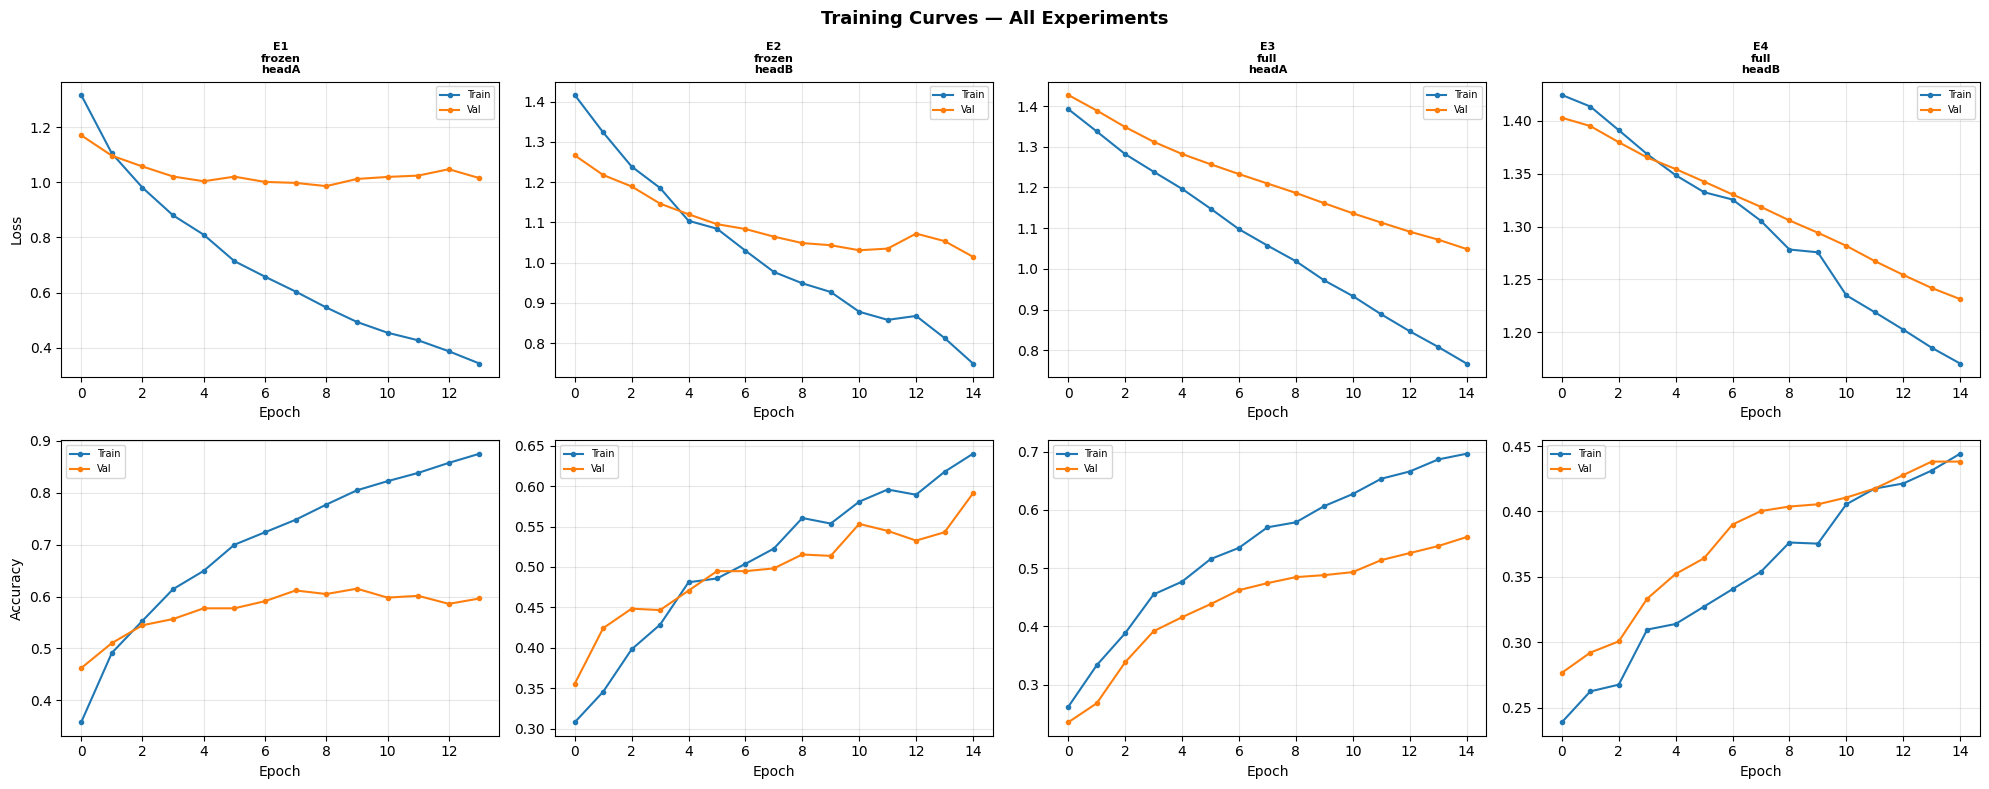

In [ ]:
# ── Training curves for all experiments ──────────────────────────────────────
fig, axes = plt.subplots(2, len(EXPERIMENTS), figsize=(5 * len(EXPERIMENTS), 8))

for col, exp in enumerate(EXPERIMENTS):
    h = experiment_histories[exp['name']]

    axes[0][col].plot(h['loss'],     label='Train', marker='o', markersize=3)
    axes[0][col].plot(h['val_loss'], label='Val',   marker='o', markersize=3)
    axes[0][col].set_title(exp['name'].replace('_', '\n'), fontsize=8, fontweight='bold')
    axes[0][col].set_xlabel('Epoch')
    axes[0][col].legend(fontsize=7)
    axes[0][col].grid(alpha=0.3)
    if col == 0:
        axes[0][col].set_ylabel('Loss')

    axes[1][col].plot(h['accuracy'],     label='Train', marker='o', markersize=3)
    axes[1][col].plot(h['val_accuracy'], label='Val',   marker='o', markersize=3)
    axes[1][col].set_xlabel('Epoch')
    axes[1][col].legend(fontsize=7)
    axes[1][col].grid(alpha=0.3)
    if col == 0:
        axes[1][col].set_ylabel('Accuracy')

plt.suptitle('Training Curves — All Experiments', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Classification Report — E1_frozen_headA:
              precision    recall  f1-score   support

 Oral Cavity       0.59      0.72      0.65       173
      Larynx       0.66      0.61      0.64       192
  Oropharynx       0.55      0.49      0.52       165
 Hypopharynx       0.64      0.54      0.58        52

    accuracy                           0.60       582
   macro avg       0.61      0.59      0.60       582
weighted avg       0.61      0.60      0.60       582



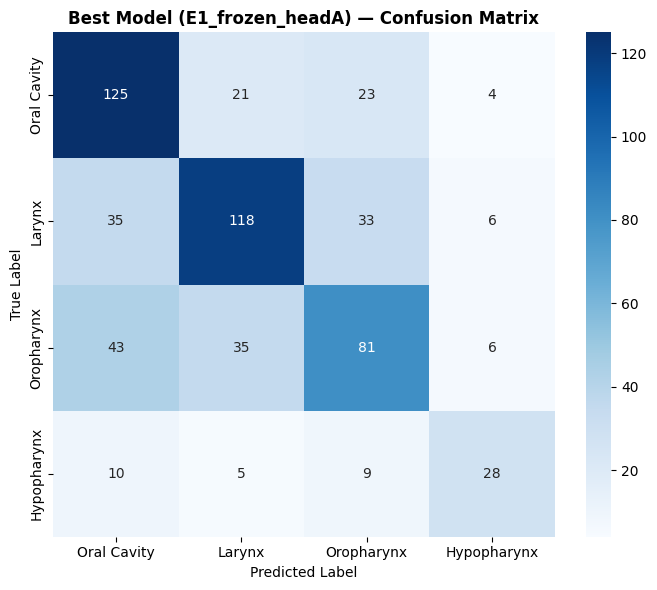

Per-class accuracy (best model):
  Oral Cavity    : 0.7225  (173 samples)
  Larynx         : 0.6146  (192 samples)
  Oropharynx     : 0.4909  (165 samples)
  Hypopharynx    : 0.5385  (52 samples)


In [ ]:
# ── Confusion matrix for best model ──────────────────────────────────────────
print(f"Classification Report — {best_exp_name}:")
print(classification_report(best_y_true, best_y_pred, target_names=SUBSITE_NAMES))

cm = confusion_matrix(best_y_true, best_y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SUBSITE_NAMES, yticklabels=SUBSITE_NAMES)
plt.title(f'Best Model ({best_exp_name}) — Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
print('Per-class accuracy (best model):')
for i, name in enumerate(SUBSITE_NAMES):
    mask = best_y_true == i
    if mask.sum() == 0:
        continue
    print(f"  {name:15s}: {(best_y_pred[mask]==i).mean():.4f}  ({mask.sum()} samples)")